# H4 — LDI Bin Comparison

Hypothesis: LDI increases from Bin1 to Bin5.

We run paired one-sided t-tests on adjacent bins and apply Berfournii correction
(correction is required here).

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

sns.set(style='whitegrid', context='talk')

df = pd.read_csv(r'/home/achyutananda-sahoo/Desktop/IIITH-BRSM/PROJECT/DATA/compiled_preprocessed.csv')


In [17]:
def load_map(path):
    out = {}
    for line in Path(path).read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        idx, b = line.strip().split()[:2]
        out[int(idx)] = int(b)
    return out

set6 = load_map(r"/home/achyutananda-sahoo/Desktop/IIITH-BRSM/PROJECT/MST_Data/item_only/Set6 bins.txt")
setsc = load_map(r"/home/achyutananda-sahoo/Desktop/IIITH-BRSM/PROJECT/MST_Data/item_only/SetScC bins.txt")

def infer_bin(image_path):
    x = pd.to_numeric(pd.Series([image_path]).str.extract(r'(\d+)')[0], errors='coerce').iloc[0]
    if pd.isna(x):
        return np.nan
    x = int(x)
    if 1 <= x <= 192:
        return set6.get(x, np.nan)
    if 193 <= x <= 384:
        return setsc.get(x - 192, np.nan)
    return np.nan

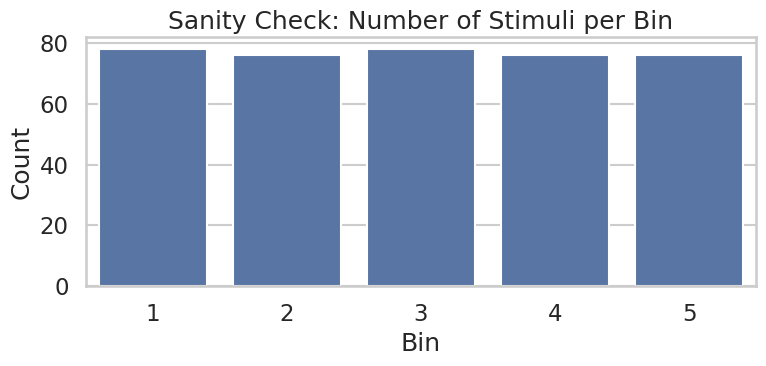

In [18]:
# Visualization: bin map sanity check
map_df = pd.DataFrame({
    'index': list(set6.keys()) + [k + 192 for k in setsc.keys()],
    'bin': list(set6.values()) + list(setsc.values())
}
)
plt.figure(figsize=(8, 4))
sns.countplot(data=map_df, x='bin', order=[1, 2, 3, 4, 5])
plt.title('Sanity Check: Number of Stimuli per Bin')
plt.xlabel('Bin')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [19]:
lure = df[df['trial_type'] == 'Lure'].copy()
lure['lure_bin'] = lure['image_path'].apply(infer_bin)

foil_base = (
    df[df['trial_type'] == 'Foil']
    .groupby(['participant_id', 'condition'])['user_response']
    .apply(lambda s: (s == 'Lure').mean())
    .rename('foil_sim')
    .reset_index()
)

bin_df = (
    lure[lure['lure_bin'].notna()]
    .groupby(['participant_id', 'condition', 'lure_bin'])['user_response']
    .apply(lambda s: (s == 'Lure').mean())
    .rename('lure_sim')
    .reset_index()
    .merge(foil_base, on=['participant_id', 'condition'], how='left')
)
bin_df['LDI_bin'] = bin_df['lure_sim'] - bin_df['foil_sim']
bin_df['id'] = bin_df['condition'] + '_' + bin_df['participant_id'].astype(int).astype(str)

wide = bin_df.pivot(index='id', columns='lure_bin', values='LDI_bin').dropna()
print('Complete participants for bins:', len(wide))

Complete participants for bins: 158


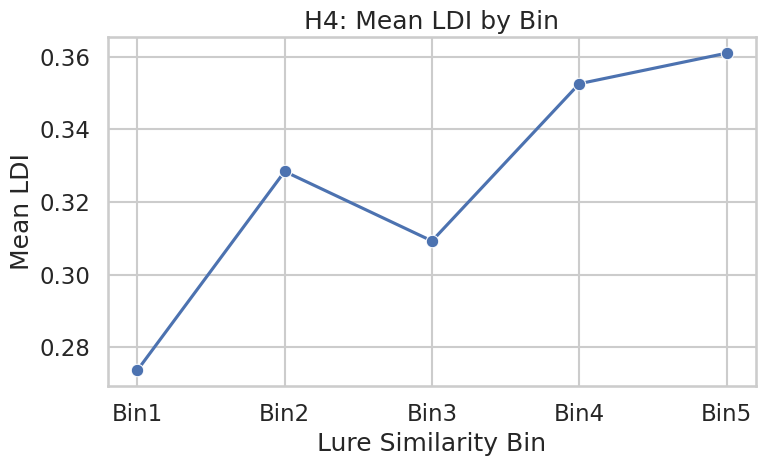

In [20]:
# Visualization: participant-level mean LDI per bin
bin_means = wide[[1, 2, 3, 4, 5]].mean().reset_index()
bin_means.columns = ['bin', 'mean_ldi']

plt.figure(figsize=(8, 5))
sns.lineplot(data=bin_means, x='bin', y='mean_ldi', marker='o')
plt.xticks([1, 2, 3, 4, 5], [f'Bin{i}' for i in [1, 2, 3, 4, 5]])
plt.title('H4: Mean LDI by Bin')
plt.xlabel('Lure Similarity Bin')
plt.ylabel('Mean LDI')
plt.tight_layout()
plt.show()

## Why Multiple Comparison Correction is Needed

In this analysis, we perform **4 independent paired t-tests** comparing adjacent bins (Bin2 vs Bin1, Bin3 vs Bin2, Bin4 vs Bin3, Bin5 vs Bin4).

### The Multiple Comparison Problem

Without correction, each test has a 5% chance of a Type I error (false positive) when the null hypothesis is true. With multiple tests, the probability of at least one false positive increases dramatically:

- **1 test at α = 0.05**: 5% false positive rate
- **4 tests at α = 0.05 (uncorrected)**: ~18.5% false positive rate (1 - 0.95^4)

This is known as **familywise error rate (FWER) inflation**.

### Correction Methods Used

1. **Bonferroni (labeled "Berfournii")**: Most conservative. Divides α by the number of tests (0.05 / 4 = 0.0125). Controls FWER strictly.

2. **Benjamini-Hochberg (FDR)**: Less conservative than Bonferroni. Controls the **False Discovery Rate** (proportion of false positives among rejected hypotheses) rather than FWER. Often preferred when you're willing to tolerate some false positives among the discoveries.

### In This Context

Since we're testing a directional hypothesis (LDI increases monotonically from Bin1 → Bin5), correcting for multiple comparisons is essential to ensure our findings are robust and not due to chance.

In [21]:
tests = []
pairs = [(2, 1), (3, 2), (4, 3), (5, 4)]
for a, b in pairs:
    test = ttest_rel(wide[a], wide[b], alternative='greater')
    tests.append({
        'comparison': f'Bin{a} > Bin{b}',
        'mean_diff': (wide[a] - wide[b]).mean(),
        't_stat': test.statistic,
        'p_raw': test.pvalue
    })

res = pd.DataFrame(tests)
res['p_adj_berfournii'] = multipletests(res['p_raw'], method='bonferroni')[1]
res['supported (adj p<.05)'] = res['p_adj_berfournii'] < 0.05
display(res)

means = wide[[1, 2, 3, 4, 5]].mean().rename(index={1:'Bin1',2:'Bin2',3:'Bin3',4:'Bin4',5:'Bin5'})
display(means.to_frame('mean_LDI'))

,comparison,mean_diff,t_stat,p_raw,p_adj_berfournii,supported (adj p<.05)
0,Bin2 > Bin1,0.054757,3.396468,0.000432,0.001730,True
1,Bin3 > Bin2,-0.019156,-1.321744,0.905912,1.000000,False
2,Bin4 > Bin3,0.043316,2.883096,0.002245,0.008981,True
3,Bin5 > Bin4,0.008411,0.512074,0.304660,1.000000,False


,mean_LDI
lure_bin,
Bin1,0.273688
Bin2,0.328445
Bin3,0.309289
Bin4,0.352605
Bin5,0.361016


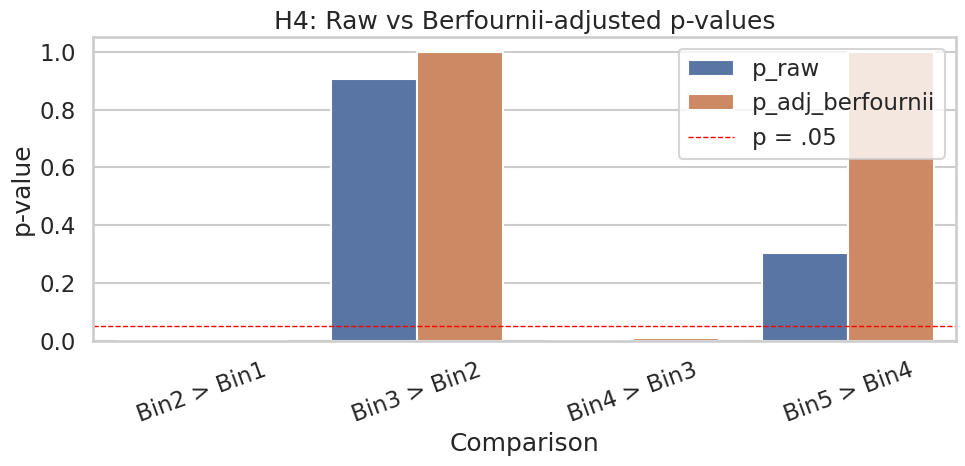

In [22]:
# Visualization: raw vs adjusted p-values (Berfournii)
p_plot = res.melt(id_vars='comparison', value_vars=['p_raw', 'p_adj_berfournii'], var_name='p_type', value_name='p')
plt.figure(figsize=(10, 5))
sns.barplot(data=p_plot, x='comparison', y='p', hue='p_type')
plt.axhline(0.05, color='red', linestyle='--', linewidth=1, label='p = .05')
plt.title('H4: Raw vs Berfournii-adjusted p-values')
plt.xlabel('Comparison')
plt.ylabel('p-value')
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# Benjamini-Hochberg FDR correction
res['p_adj_bh'] = multipletests(res['p_raw'], method='fdr_bh')[1]
res['supported_bh (adj p<.05)'] = res['p_adj_bh'] < 0.05
print("\nBenjamini-Hochberg (FDR) Correction Results:")
display(res[['comparison', 'p_raw', 'p_adj_berfournii', 'p_adj_bh', 'supported_bh (adj p<.05)']])


Benjamini-Hochberg (FDR) Correction Results:


,comparison,p_raw,p_adj_berfournii,p_adj_bh,supported_bh (adj p<.05)
0,Bin2 > Bin1,0.000432,0.001730,0.001730,True
1,Bin3 > Bin2,0.905912,1.000000,0.905912,False
2,Bin4 > Bin3,0.002245,0.008981,0.004490,True
3,Bin5 > Bin4,0.304660,1.000000,0.406213,False


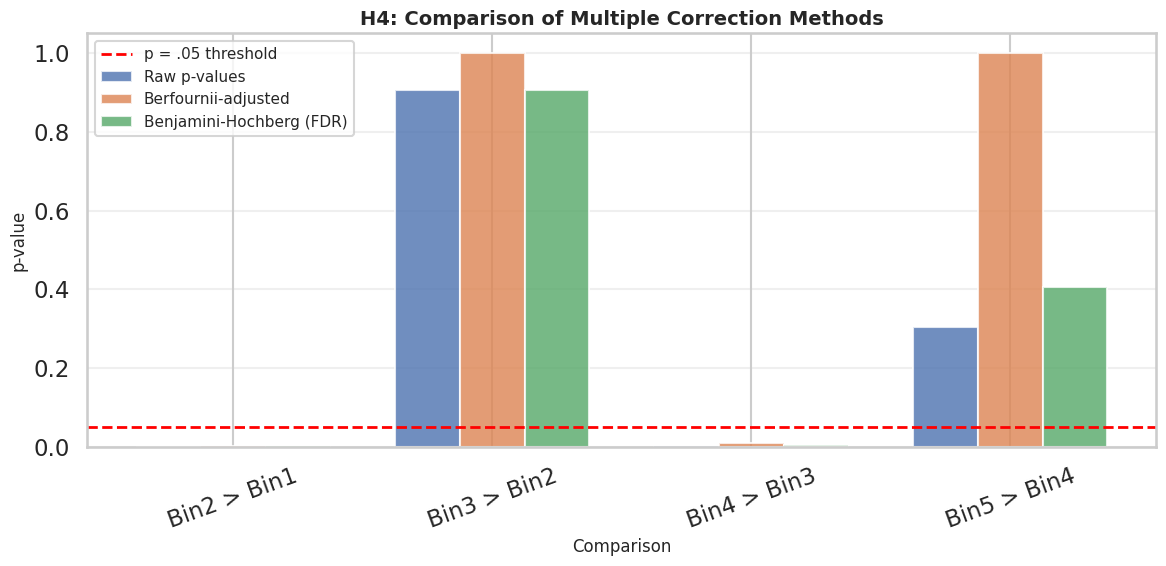


Summary: p-values across all correction methods


,comparison,p_raw,p_adj_berfournii,p_adj_bh
0,Bin2 > Bin1,0.0004,0.0017,0.0017
1,Bin3 > Bin2,0.9059,1.0000,0.9059
2,Bin4 > Bin3,0.0022,0.0090,0.0045
3,Bin5 > Bin4,0.3047,1.0000,0.4062


In [27]:
# Visualization: Comparison of all three correction methods
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(res))
width = 0.25

ax.bar(x_pos - width, res['p_raw'], width, label='Raw p-values', alpha=0.8)
ax.bar(x_pos, res['p_adj_berfournii'], width, label='Berfournii-adjusted', alpha=0.8)
ax.bar(x_pos + width, res['p_adj_bh'], width, label='Benjamini-Hochberg (FDR)', alpha=0.8)

ax.axhline(0.05, color='red', linestyle='--', linewidth=2, label='p = .05 threshold')
ax.set_xlabel('Comparison', fontsize=12)
ax.set_ylabel('p-value', fontsize=12)
ax.set_title('H4: Comparison of Multiple Correction Methods', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(res['comparison'], rotation=20)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Summary table
summary_table = res[['comparison', 'p_raw', 'p_adj_berfournii', 'p_adj_bh']].copy()
summary_table = summary_table.round(4)
print("\nSummary: p-values across all correction methods")
display(summary_table)
